# 1. Data Preparing

* 1.1 Import relevant packages

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pandas.plotting import scatter_matrix
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

sns.set(color_codes=True)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

* 1.2 Import the data and since the raw data has no title, they are imported with the names given to each column.

In [16]:
one = pd.read_csv(
    "./input/1.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
one.drop('Sequence', axis=1, inplace=True)

two = pd.read_csv(
    "./input/2.csv"
    ,names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
two.drop('Sequence', axis=1, inplace=True)

three = pd.read_csv(
    "./input/3.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
three.drop('Sequence', axis=1, inplace=True)

four = pd.read_csv(
    "./input/4.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
four.drop('Sequence', axis=1, inplace=True)

five = pd.read_csv(
    "./input/5.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
five.drop('Sequence', axis=1, inplace=True)

six = pd.read_csv(
    "./input/6.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
six.drop('Sequence', axis=1, inplace=True)

seven = pd.read_csv(
    "./input/7.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
seven.drop('Sequence', axis=1, inplace=True)

eight = pd.read_csv(
    "./input/8.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
eight.drop('Sequence', axis=1, inplace=True)

nine = pd.read_csv(
    "./input/9.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
nine.drop('Sequence', axis=1, inplace=True)

ten = pd.read_csv(
    "./input/10.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
ten.drop('Sequence', axis=1, inplace=True)

eleven = pd.read_csv(
    "./input/11.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
eleven.drop('Sequence', axis=1, inplace=True)

twelve = pd.read_csv(
    "./input/12.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
twelve.drop('Sequence', axis=1, inplace=True)

thirteen = pd.read_csv(
    "./input/13.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
thirteen.drop('Sequence', axis=1, inplace=True)

fourteen = pd.read_csv(
    "./input/14.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
fourteen.drop('Sequence', axis=1, inplace=True)

fifteen = pd.read_csv(
    "./input/15.csv",
    names=['Sequence', 'x_acceleration', 'y_acceleration', 'z_acceleration', 'Labels'])
fifteen.drop('Sequence', axis=1, inplace=True)

* 1.3 Add a new column called "Persn" and merge all the columns to a dataframe.

In [18]:
one['Person'] = 1
two['Person'] = 2
three['Person'] = 3
four['Person'] = 4
five['Person'] = 5
six['Person'] = 6
seven['Person'] = 7
eight['Person'] = 8
nine['Person'] = 9
ten['Person'] = 10
eleven['Person'] = 11
twelve['Person'] = 12
thirteen['Person'] = 13
fourteen['Person'] = 14
fifteen['Person'] = 15   #15 Participants and 7 Activities


frames = [one, two, three, four, five, six, seven, eight, nine, ten, eleven, twelve, thirteen, fourteen, fifteen]
df = pd.concat(frames)   
print(df.shape)  
print(df.head())

(1926896, 5)
   x_acceleration  y_acceleration  z_acceleration  Labels  Person
0            1502            2215            2153       1       1
1            1667            2072            2047       1       1
2            1611            1957            1906       1       1
3            1601            1939            1831       1       1
4            1643            1965            1879       1       1


* 1.4 Due to the large amount of sample data, we choose to sample randomly.And then we know briefly the basic information of the data set.

In [20]:
df_rnd = df.sample(n=100000, random_state=6758)  # Sampling randomly according to a certain number 

df_rnd_2 = df.sample(frac=0.5)
print(df_rnd_2.shape)                            # Sampling randomly according to a certain scale 

(963448, 5)


In [21]:
df_rnd = df_rnd[df_rnd['Labels'] != 0]  # There are only seven categories in the actual problem, so we remove data which are labeled 0.
print(df_rnd.shape)
print(df_rnd['Labels'].value_counts())

(99819, 5)
Labels
1    31627
7    30770
4    18590
3    11178
5     2785
2     2498
6     2371
Name: count, dtype: int64


In [22]:
print(df_rnd.dtypes, df_rnd.isna().sum())
print(df_rnd.describe())

print(df_rnd.groupby('Labels').mean())  

x_acceleration    int64
y_acceleration    int64
z_acceleration    int64
Labels            int64
Person            int64
dtype: object x_acceleration    0
y_acceleration    0
z_acceleration    0
Labels            0
Person            0
dtype: int64
       x_acceleration  y_acceleration  z_acceleration        Labels  \
count    99819.000000    99819.000000    99819.000000  99819.000000   
mean      1987.307336     2381.967471     1970.829041      3.887617   
std        111.369988      100.211564       94.573223      2.438922   
min        483.000000       74.000000     1157.000000      1.000000   
25%       1904.000000     2337.000000     1918.000000      1.000000   
50%       1991.000000     2366.000000     1988.000000      4.000000   
75%       2076.000000     2411.000000     2033.000000      7.000000   
max       2895.000000     2968.000000     4095.000000      7.000000   

             Person  
count  99819.000000  
mean       7.518589  
std        4.185780  
min        1.000000  
25%

From the above means,it seems that y_acceleration always keeps biggest regardless of seven activities.In addition, x_acceleration's maximum is label 5 and label 6 , namely "Going UpDown Stairs"and " Walking and Talking with Someone", y_acceleration's minimun is label 2, namely"Standing Up, Walking and Going updown stairs", z_acceleration's maximum is label 5, namely "Going UpDown Stairs".

# 2. Data Exploring

* 2.1 Explore relationships between attributes and visualization.

/var/folders/8z/z9t9g5792h5785sr4t5q7scr0000gn/T/ipykernel_99085/136514995.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_rnd[['x_acceleration', 'y_acceleration', 'z_acceleration']],


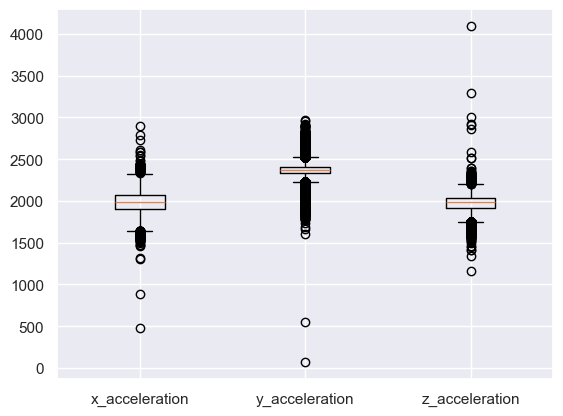

In [26]:
plt.boxplot(df_rnd[['x_acceleration', 'y_acceleration', 'z_acceleration']],
            labels=['x_acceleration', 'y_acceleration', 'z_acceleration'])
plt.show()

    x_acceleration  y_acceleration  z_acceleration  Labels  Person
84            1670            2147            2079       1       1
88            1726            2203            2005       1       1
89            1778            2143            1946       1       1
90            1718            2102            2012       1       1
93            1664            2241            2064       1       1


/var/folders/8z/z9t9g5792h5785sr4t5q7scr0000gn/T/ipykernel_99085/3561576925.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(temp[['x_acceleration', 'y_acceleration', 'z_acceleration']],


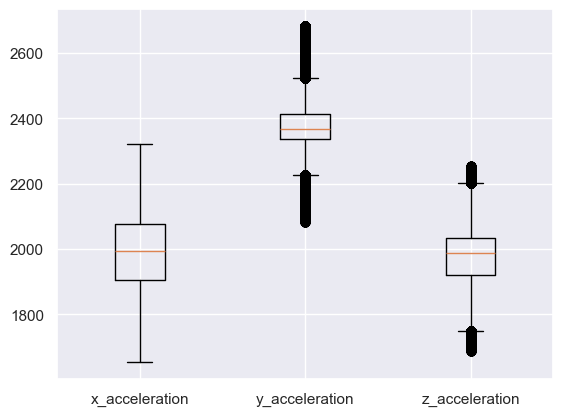

In [27]:
temp = df[(np.abs(stats.zscore(df)) < 3).all(axis=1)]  
print(temp.head())
plt.boxplot(temp[['x_acceleration', 'y_acceleration', 'z_acceleration']],
            labels=['x_acceleration', 'y_acceleration', 'z_acceleration'])
plt.show()

The boxplot of non-outliers for data according to zscore.

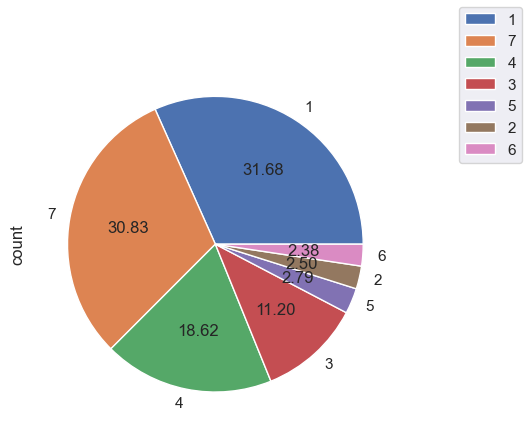

In [29]:
df_rnd['Labels'].value_counts().plot(kind='pie', autopct='%.2f')  
plt.figlegend()  
plt.show()  

According to the pie chart, it can be determined that Label 1, 4 and 7 account for the largest proportion, namely Working at Computer, Walking, Talking while Standing respectively.

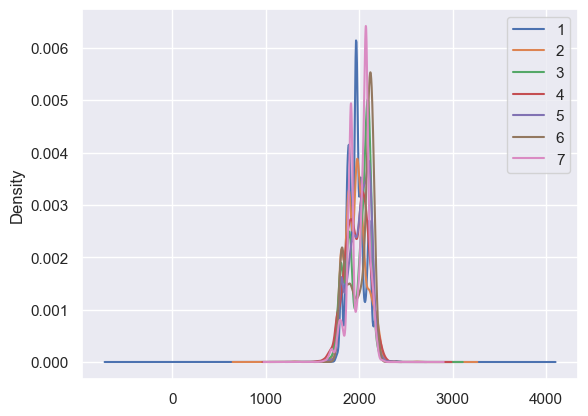

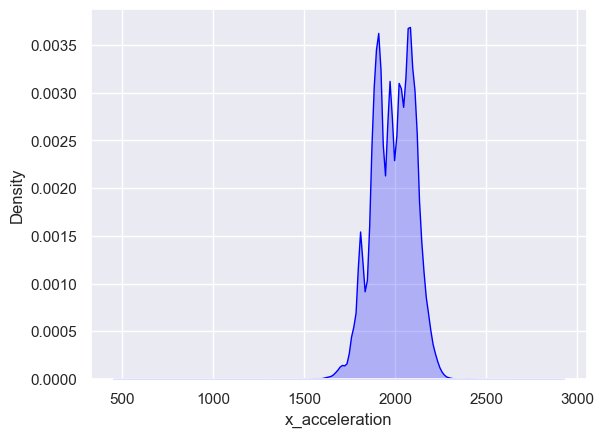

In [31]:
df_rnd.groupby('Labels')['x_acceleration'].plot.kde()   
plt.autoscale(enable=True, axis='both', tight=None)
plt.legend()
plt.show()

sns.kdeplot(df_rnd["x_acceleration"], fill=True, color='blue')
plt.show()

According to the kernel density,we can know that x_acceleration is between 1600 and 2300.In addition, label 7 and label 1 have the highest probability,namely Talking while Standing and Working at Computer respectively.

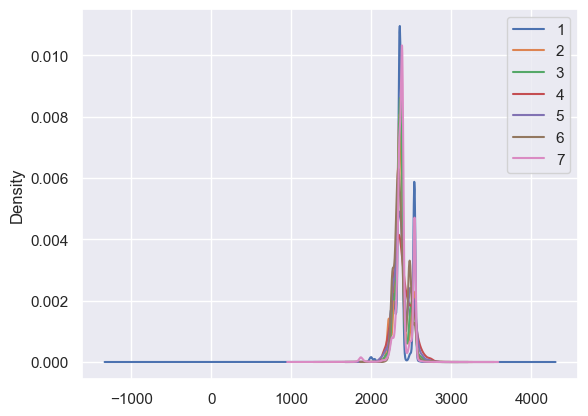

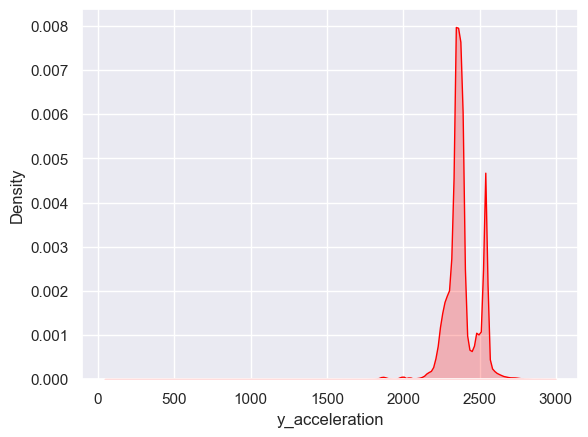

In [33]:
df_rnd.groupby('Labels')['y_acceleration'].plot.kde()
plt.autoscale(enable=True, axis='both', tight=None)
plt.legend()
plt.show()

sns.kdeplot(df_rnd["y_acceleration"], fill=True, color='red')
plt.show()

According to the kernel density,we can know that y_acceleration is between 2200 and 2800.In addition, label 1 and label 7 have the highest probability,namely Working at Computer  and Talking while Standing respectively.

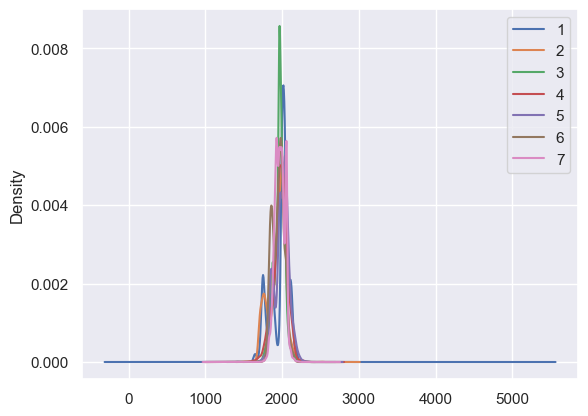

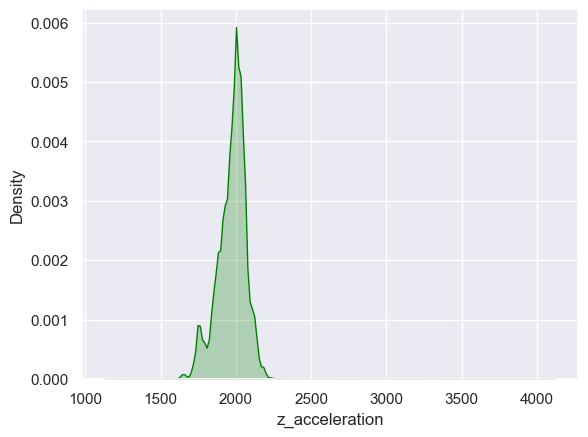

In [35]:
df_rnd.groupby('Labels')['z_acceleration'].plot.kde()
plt.autoscale(enable=True, axis='both', tight=None)
plt.legend()
plt.show()

sns.kdeplot(df_rnd["z_acceleration"], fill=True, color='green')
plt.show()

According to the kernel density,we can know that z_acceleration is between 1600 and 2300.In addition, label 3 and label 1 have the highest probability, namely Standing and Working at Computer respectively.

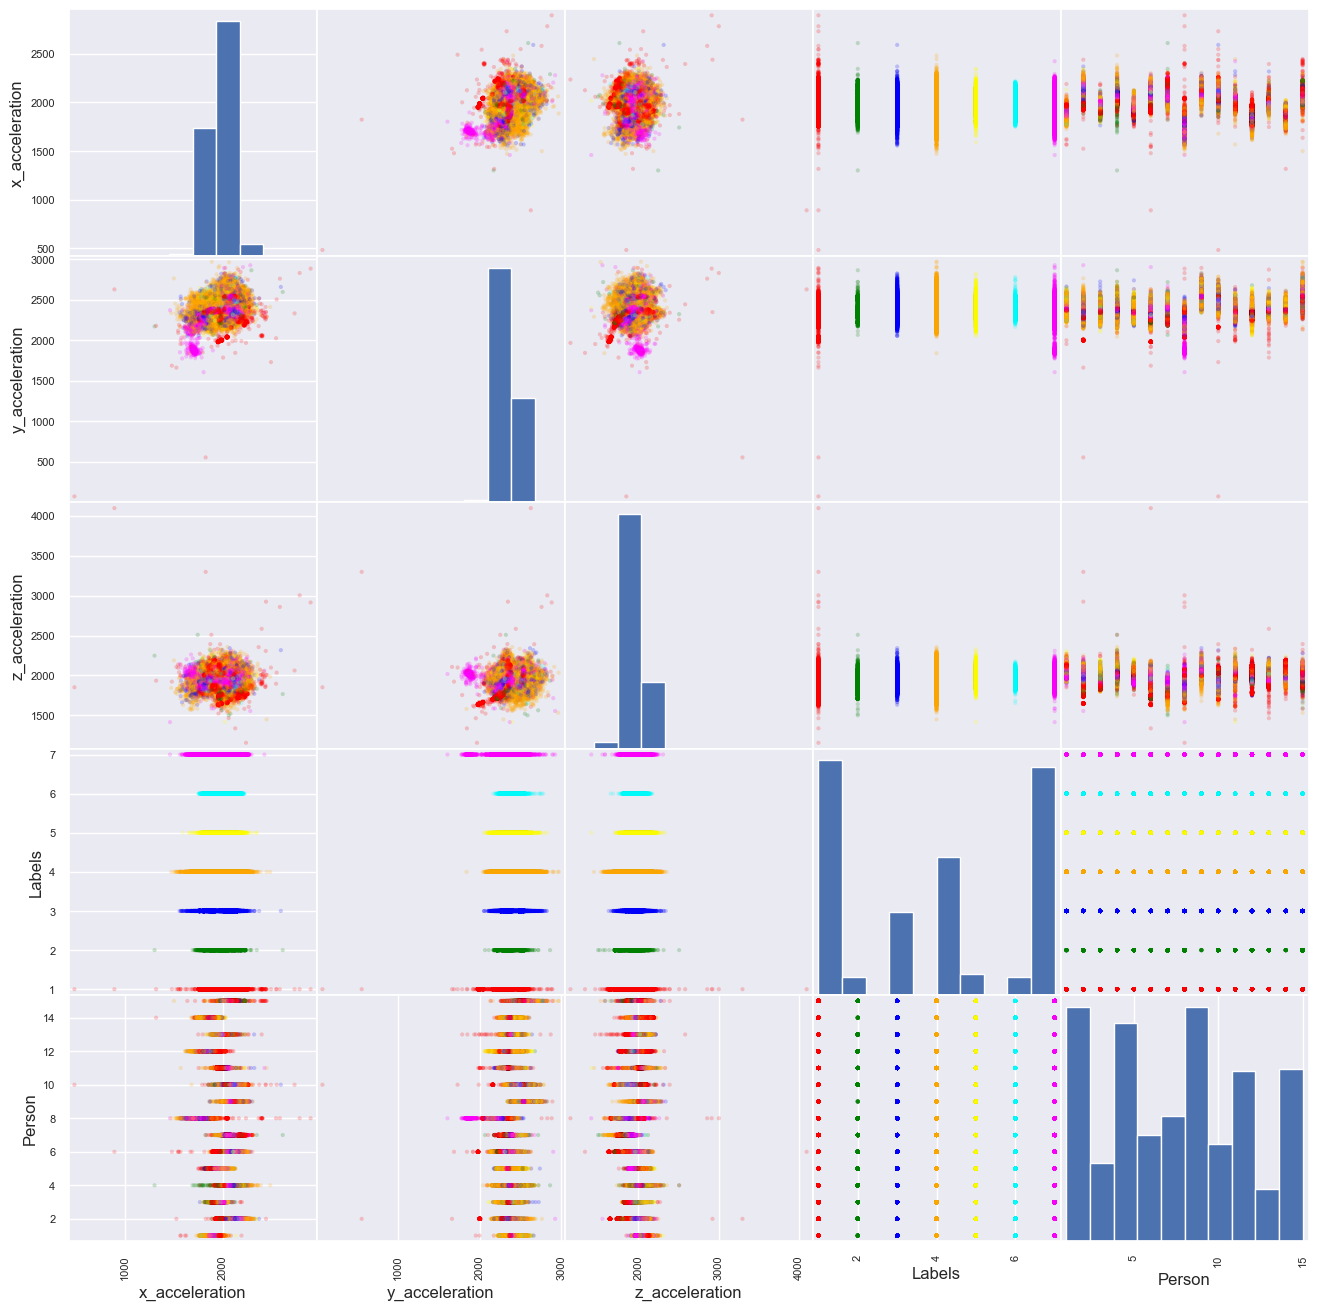

In [37]:
colors_palette = {1: 'red', 2: 'green', 3: 'blue', 4: 'orange', 5: 'yellow', 6: 'cyan', 7: 'magenta'}
colors = [colors_palette[c] for c in df_rnd['Labels']]
scatter_matrix(df_rnd, alpha=0.2, figsize=(16, 16), diagonal='hist', c=colors)
plt.show()

                x_acceleration  y_acceleration  z_acceleration    Labels  \
x_acceleration        1.000000        0.371044        0.015191  0.079724   
y_acceleration        0.371044        1.000000        0.340963  0.044100   
z_acceleration        0.015191        0.340963        1.000000  0.030303   
Labels                0.079724        0.044100        0.030303  1.000000   
Person               -0.018510        0.284180        0.127364 -0.174606   

                  Person  
x_acceleration -0.018510  
y_acceleration  0.284180  
z_acceleration  0.127364  
Labels         -0.174606  
Person          1.000000  


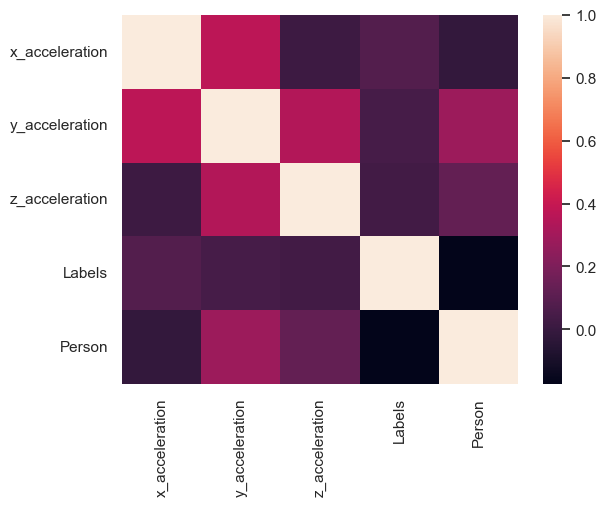

In [38]:
print(df_rnd.corr(method='pearson'))

sns.heatmap(df_rnd.corr(method='pearson'))
plt.show()

We can know the correlation between those attributes according the scatter_matrix figure and heatmap.Correlations between the accelerations are close to 0.5, however, between the accalerations and labels are close to 0.1 merely.

# 3. Data Modeling 

* 3.1 Identify factors and response, data encoding, data normalization and standardization, and divide the data into training set and testing set.

In [42]:
print(df['Labels'].value_counts())

Data = df_rnd.drop(columns=['Person', 'Labels']).values
target = df_rnd['Labels'].values
print(Data.shape)
print(target.shape)

Labels
1    608667
7    593563
4    357064
3    216737
5     51498
2     47878
6     47770
0      3719
Name: count, dtype: int64
(99819, 3)
(99819,)


In [43]:
from sklearn import preprocessing

my_label = preprocessing.LabelEncoder()  
target = my_label.fit_transform(target)

# target=preprocessing.LabelEncoder().fit_transform(target)
print(np.unique(target))

[0 1 2 3 4 5 6]


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(Data)

# Data=preprocessing.StandardScaler().fit_transform(Data)

StandardScaler()

In [45]:
from sklearn.model_selection import train_test_split

D_train, D_test, t_train, t_test = train_test_split(Data, target, test_size=0.3, random_state=6758)
print(D_train.shape,D_test.shape,t_train.shape,t_test.shape)

(69873, 3) (29946, 3) (69873,) (29946,)


* 3.2 Data modeling:K_Nearest_Neighbor Classifier and Decision Tree Classifier

In [47]:
# Fitting a classifier 
# K-Nearest_Neighbor Classifier
from sklearn.neighbors import KNeighborsClassifier

knn_classifier = KNeighborsClassifier()
knn_classifier.fit(D_train, t_train)
kNN = knn_classifier.score(D_test, t_test)
print('KNN Classification:', kNN)  
print(D_train)

KNN Classification: 0.7175916649969946
[[1885 2387 2078]
 [1899 2413 1983]
 [1871 2383 2043]
 ...
 [1887 2366 1964]
 [1798 2321 2097]
 [2234 2525 2039]]


array([3, 3, 0, 6, 6, 0, 3, 2, 3, 0])

In [48]:
# Decison Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=6578)
dt_classifier.fit(D_train, t_train)
dT = dt_classifier.score(D_test, t_test)
print('DecisionTree Classifier:', dT)

DecisionTree Classifier: 0.51829960595739


* 3.3 Adjust parameter to achieve model optimization

In [50]:
cv_method = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=6758)

params_KNN = {'n_neighbors': [1, 3, 5, 7, 11, 15, 20, 25], 'p': [1, 2, 5]}

gs_KNN = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=params_KNN,
                      cv=cv_method, verbose=1, scoring='accuracy', n_jobs=-2,
                      return_train_score=True)

gs_KNN.fit(Data, target)  # Fitting 15 folds for each of 24 candidates, totalling 360 fits
print("最优参数:",gs_KNN.best_params_, gs_KNN.best_score_, gs_KNN.cv_results_['mean_test_score'])  #{'n_neighbors': 20, 'p': 2}

results_KNN = pd.DataFrame(gs_KNN.cv_results_['params'])
results_KNN['test_score'] = gs_KNN.cv_results_['mean_test_score']
results_KNN['metric'] = results_KNN['p'].replace([1, 2, 5], ['Manhatten', 'Euclidean', 'Minkowski'])

print(results_KNN)

Fitting 15 folds for each of 24 candidates, totalling 360 fits
最优参数: {'n_neighbors': 25, 'p': 2} 0.7414754129775764 [0.65965063 0.65942355 0.6591564  0.69817037 0.69842414 0.69825384
 0.72004997 0.72093823 0.72107514 0.72964733 0.73009481 0.73015826
 0.73752159 0.73823621 0.73783882 0.73997269 0.74027991 0.74032333
 0.74110474 0.74145204 0.74125167 0.74116485 0.74147541 0.74106466]
    n_neighbors  p  test_score     metric
0             1  1    0.659651  Manhatten
1             1  2    0.659424  Euclidean
2             1  5    0.659156  Minkowski
3             3  1    0.698170  Manhatten
4             3  2    0.698424  Euclidean
5             3  5    0.698254  Minkowski
6             5  1    0.720050  Manhatten
7             5  2    0.720938  Euclidean
8             5  5    0.721075  Minkowski
9             7  1    0.729647  Manhatten
10            7  2    0.730095  Euclidean
11            7  5    0.730158  Minkowski
12           11  1    0.737522  Manhatten
13           11  2    0.738

In [51]:
df_classifier = DecisionTreeClassifier(random_state=6758)
params_DT = {'criterion': ['gini', 'entropy'],
             'max_depth': [5, 6, 7, 8, 10, 12, 15, 17],
             'min_samples_split': [2, 3]}
gs_DT = GridSearchCV(estimator=df_classifier, param_grid=params_DT, cv=cv_method, verbose=1, n_jobs=-2,
                     scoring='accuracy')

gs_DT.fit(Data, target)
print("最优参数:",gs_DT.best_params_, gs_DT.best_score_)
#{'criterion': 'gini', 'max_depth': 12, 'min_samples_split': 3}
results_DT = pd.DataFrame(gs_DT.cv_results_['params'])
results_DT['test_score'] = gs_DT.cv_results_['mean_test_score']
print(results_DT)

Fitting 15 folds for each of 32 candidates, totalling 480 fits
最优参数: {'criterion': 'gini', 'max_depth': 12, 'min_samples_split': 3} 0.714052450984766
   criterion  max_depth  min_samples_split  test_score
0       gini          5                  2    0.588549
1       gini          5                  3    0.588549
2       gini          6                  2    0.618673
3       gini          6                  3    0.618673
4       gini          7                  2    0.647028
5       gini          7                  3    0.647041
6       gini          8                  2    0.665621
7       gini          8                  3    0.665615
8       gini         10                  2    0.700531
9       gini         10                  3    0.700548
10      gini         12                  2    0.714039
11      gini         12                  3    0.714052
12      gini         15                  2    0.706702
13      gini         15                  3    0.706278
14      gini         17  

* 3.4 Predicting and choose evaluation index

In [53]:
# Predicting
t_pred_knn = gs_KNN.predict(D_test)
print('KNN Predicted accuracy score:', metrics.accuracy_score(t_test, t_pred_knn))

t_pred_dt = gs_DT.predict(D_test)
print("DecisionTree accuracy score:", metrics.accuracy_score(t_test, t_pred_dt))

KNN Predicted accuracy score: 0.7524210245107861
DecisionTree accuracy score: 0.749582581980899


In [54]:
print(metrics.confusion_matrix(t_test, t_pred_knn))

print(metrics.classification_report(t_test, t_pred_knn))

[[8656   46  104  225    7    3  370]
 [ 324  111   42  140    2    1  127]
 [ 223    8 1682  710   55   25  735]
 [ 499   11  259 4016   13   16  701]
 [  97    0  157  360   79    3  140]
 [  42    3  114  134   21  122  314]
 [ 417   16  349  519   21   61 7866]]
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      9411
           1       0.57      0.15      0.24       747
           2       0.62      0.49      0.55      3438
           3       0.66      0.73      0.69      5515
           4       0.40      0.09      0.15       836
           5       0.53      0.16      0.25       750
           6       0.77      0.85      0.81      9249

    accuracy                           0.75     29946
   macro avg       0.63      0.48      0.51     29946
weighted avg       0.73      0.75      0.73     29946



In [55]:
print(metrics.confusion_matrix(t_test, t_pred_dt))

print(metrics.classification_report(t_test, t_pred_dt))

[[8461   43  123  253    5    2  524]
 [ 251  145   28  135    1    0  187]
 [ 216    7 1650  651   65   25  824]
 [ 394   10  289 4084   11    8  719]
 [  80    4  151  320  102    6  173]
 [  30    4  103  142   26  126  319]
 [ 383    8  393  524   17   45 7879]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      9411
           1       0.66      0.19      0.30       747
           2       0.60      0.48      0.53      3438
           3       0.67      0.74      0.70      5515
           4       0.45      0.12      0.19       836
           5       0.59      0.17      0.26       750
           6       0.74      0.85      0.79      9249

    accuracy                           0.75     29946
   macro avg       0.65      0.49      0.52     29946
weighted avg       0.74      0.75      0.73     29946



In both model, the indicators of labels 4 and 5 are not very good, while the other labels perform well.